In [62]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("datasets/dataset-tickets-multi-lang-4-20k.csv")

In [20]:
df

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
1,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
2,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN
3,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN
4,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,en,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11918,Guidelines for Securing Medical Data in OBS St...,Seeking details on securing medical data using...,Offering general security guidelines for OBS S...,Request,Technical Support,high,en,Security,Documentation,IT,NaN,NaN,NaN,NaN,NaN
11919,NaN,Can you provide information on digital strateg...,I would be happy to discuss digital strategies...,Request,Billing and Payments,medium,en,Feedback,Sales,Lead,NaN,NaN,NaN,NaN,NaN
11920,Support for Marketing Enhancements,Request for assistance in improving digital ma...,Ready to help with your marketing support need...,Change,Technical Support,high,en,Feedback,Sales,Marketing,Documentation,Tech Support,NaN,NaN,NaN
11921,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,Integration,Disruption,Performance,IT,Tech Support,NaN,NaN,NaN


In [18]:
df['language'].value_counts()

language
en    11923
Name: count, dtype: int64

In [ ]:
df1 = df[df["language"] == "en"]
df1.to_csv("datasets/dataset-tickets-multi-lang-4-20k.csv", index=False)

In [ ]:
df2=pd.read_csv("datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv")
df2 = df2[df2["language"] == "en"]
df2.to_csv("datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv", index=False)

In [29]:
df2['language'].value_counts()

language
en    16338
Name: count, dtype: int64

In [ ]:
df3=pd.read_csv("datasets/dataset-tickets-multi-lang3-4k.csv")

In [ ]:
df3['language'].value_counts()
df3=df3[df3['language']=='en']
df3.to_csv("datasets/dataset-tickets-multi-lang3-4k.csv", index=False)

In [34]:
df3['language'].value_counts()

language
en    1391
Name: count, dtype: int64

In [38]:
for name, data in [("df1", df1), ("df2", df2), ("df3", df3)]:
    print(name)
    print(data.columns.tolist())
    print()

df1
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

df2
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

df3
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9']



In [39]:
fdf = pd.concat([df1, df2, df3], ignore_index=True)

In [41]:
fdf['language'].value_counts()

language
en    29652
Name: count, dtype: int64

In [43]:
fdf['body'].duplicated().sum()

np.int64(4596)

In [46]:
print(fdf.shape)
print(fdf['body'].isna().sum())


(29652, 18)
2


In [45]:
g = fdf.groupby('body')[['type', 'priority']].nunique()
print("same text, different type:", (g['type'] > 1).sum())
print("same text, different priority:", (g['priority'] > 1).sum())

same text, different type: 2
same text, different priority: 7


In [47]:
fdf = fdf.dropna(subset=['body']).copy()
fdf['text'] = fdf['subject'].fillna('') + ' ' + fdf['body']
fdf = fdf.drop_duplicates(subset='text').reset_index(drop=True)

df = fdf[['text', 'type', 'priority']].copy()   # baaki 15 columns ki zaroorat nahi
print(df.shape)
print(df['type'].value_counts())
print(df['priority'].value_counts())

(25137, 3)
type
Incident    10023
Request      7253
Problem      5199
Change       2662
Name: count, dtype: int64
priority
medium    10310
high       9743
low        5084
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['type'],
    random_state=42
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape, test_df.shape)
print(train_df['priority'].value_counts(normalize=True).round(3))
print(test_df['priority'].value_counts(normalize=True).round(3))

(20109, 3) (5028, 3)
priority
medium    0.410
high      0.388
low       0.202
Name: proportion, dtype: float64
priority
medium    0.412
high      0.386
low       0.203
Name: proportion, dtype: float64


In [58]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

for target in ['type', 'priority']:
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(train_df[['text']], train_df[target])
    pred = dummy.predict(test_df[['text']])
    print(target,
          "| accuracy:", round(accuracy_score(test_df[target], pred), 3),
          "| macro-F1:", round(f1_score(test_df[target], pred, average='macro'), 3))

type | accuracy: 0.399 | macro-F1: 0.143
priority | accuracy: 0.412 | macro-F1: 0.194


In [61]:
import time
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-small-en-v1.5')
model.max_seq_length = 256

start = time.time()
_ = model.encode(train_df['text'].tolist()[:500], batch_size=32, normalize_embeddings=True)
print("500 tickets:", round(time.time() - start, 1), "seconds")

c:\Users\utg18\OneDrive\Desktop\NLP Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\utg18\OneDrive\Desktop\NLP Project\venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\utg18\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator

500 tickets: 26.2 seconds


In [63]:
model = SentenceTransformer('BAAI/bge-small-en-v1.5')
model.max_seq_length = 256

X_train = model.encode(
    train_df['text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save('X_train.npy', X_train)

X_test = model.encode(
    test_df['text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save('X_test.npy', X_test)

print(X_train.shape, X_test.shape)

Batches: 100%|██████████| 158/158 [02:56<00:00,  1.12s/it]

(20109, 384) (5028, 384)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

for target in ['type', 'priority']:
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, train_df[target])
    pred = clf.predict(X_test)

    print("=====", target, "=====")
    print("accuracy:", round(accuracy_score(test_df[target], pred), 3))
    print("macro-F1:", round(f1_score(test_df[target], pred, average='macro'), 3))
    print(classification_report(test_df[target], pred))

===== type =====
accuracy: 0.79
macro-F1: 0.762
              precision    recall  f1-score   support

      Change       0.96      0.87      0.91       532
    Incident       0.70      0.90      0.79      2005
     Problem       0.60      0.29      0.39      1040
     Request       0.95      0.97      0.96      1451

    accuracy                           0.79      5028
   macro avg       0.80      0.76      0.76      5028
weighted avg       0.78      0.79      0.77      5028

===== priority =====
accuracy: 0.492
macro-F1: 0.396
              precision    recall  f1-score   support

        high       0.54      0.54      0.54      1939
         low       0.39      0.06      0.10      1019
      medium       0.46      0.66      0.55      2070

    accuracy                           0.49      5028
   macro avg       0.47      0.42      0.40      5028
weighted avg       0.48      0.49      0.45      5028



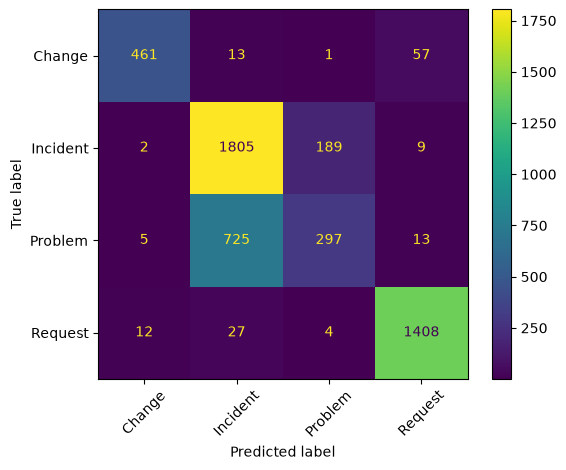

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf_type = LogisticRegression(max_iter=1000)
clf_type.fit(X_train, train_df['type'])
pred_type = clf_type.predict(X_test)

ConfusionMatrixDisplay.from_predictions(test_df['type'], pred_type, xticks_rotation=45)
plt.show()

In [67]:
clf_p = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_p.fit(X_train, train_df['priority'])
pred_p = clf_p.predict(X_test)

print("accuracy:", round(accuracy_score(test_df['priority'], pred_p), 3))
print("macro-F1:", round(f1_score(test_df['priority'], pred_p, average='macro'), 3))
print(classification_report(test_df['priority'], pred_p))

accuracy: 0.449
macro-F1: 0.443
              precision    recall  f1-score   support

        high       0.56      0.53      0.54      1939
         low       0.30      0.53      0.38      1019
      medium       0.50      0.34      0.40      2070

    accuracy                           0.45      5028
   macro avg       0.45      0.46      0.44      5028
weighted avg       0.48      0.45      0.45      5028



In [68]:
clf_type_b = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_type_b.fit(X_train, train_df['type'])
pred_b = clf_type_b.predict(X_test)

print("accuracy:", round(accuracy_score(test_df['type'], pred_b), 3))
print("macro-F1:", round(f1_score(test_df['type'], pred_b, average='macro'), 3))
print(classification_report(test_df['type'], pred_b))

accuracy: 0.757
macro-F1: 0.777
              precision    recall  f1-score   support

      Change       0.89      0.92      0.91       532
    Incident       0.77      0.63      0.69      2005
     Problem       0.48      0.65      0.55      1040
     Request       0.96      0.95      0.96      1451

    accuracy                           0.76      5028
   macro avg       0.78      0.79      0.78      5028
weighted avg       0.78      0.76      0.76      5028



In [70]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_basic(t):
    t = t.lower()
    t = re.sub(r'[^\w\s]', ' ', t)      # punctuation hatao
    t = re.sub(r'\s+', ' ', t).strip()  # extra spaces hatao
    return t

def clean_stop(t):
    words = clean_basic(t).split()
    return ' '.join(w for w in words if w not in ENGLISH_STOP_WORDS)

for d in [train_df, test_df]:
    d['text_basic'] = d['text'].apply(clean_basic)
    d['text_stop'] = d['text'].apply(clean_stop)

print(train_df['text'][0][:200])
print(train_df['text_basic'][0][:200])
print(train_df['text_stop'][0][:200])

Recurring Login Challenges with User Account The user has reported recurring login difficulties. This might be due to server overload. They have already attempted clearing their browser cache and rese
recurring login challenges with user account the user has reported recurring login difficulties this might be due to server overload they have already attempted clearing their browser cache and resett
recurring login challenges user account user reported recurring login difficulties server overload attempted clearing browser cache resetting password issue persists assistance needed resolve issue


In [71]:
for name in ['text_basic', 'text_stop']:
    Xtr = model.encode(train_df[name].tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True)
    Xte = model.encode(test_df[name].tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True)
    np.save(f'X_train_{name}.npy', Xtr)
    np.save(f'X_test_{name}.npy', Xte)
    print(name, "done", Xtr.shape)

Batches: 100%|██████████| 158/158 [03:00<00:00,  1.14s/it]


text_basic done (20109, 384)


Batches: 100%|██████████| 158/158 [02:10<00:00,  1.21it/s]

text_stop done (20109, 384)


In [72]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

tr_idx = np.load('tr_idx.npy')
te_idx = np.load('te_idx.npy')

# labels bhi purane order mein jodo (embeddings ka order yahi hai)
y_all = pd.concat([train_df[['type', 'priority']], test_df[['type', 'priority']]], ignore_index=True)
print(y_all.iloc[te_idx]['type'].value_counts(normalize=True).round(3))   # Incident 0.399 aana chahiye

versions = {'raw': '', 'basic': '_text_basic', 'stop': '_text_stop'}
rows = []

for v, suf in versions.items():
    X_all = np.vstack([np.load(f'X_train{suf}.npy'), np.load(f'X_test{suf}.npy')])
    assert len(X_all) == len(y_all)
    for target in ['type', 'priority']:
        clf = LogisticRegression(max_iter=1000, class_weight='balanced')
        clf.fit(X_all[tr_idx], y_all[target].iloc[tr_idx])
        pred = clf.predict(X_all[te_idx])
        yt = y_all[target].iloc[te_idx]
        rows.append({'version': v, 'target': target,
                     'accuracy': round(accuracy_score(yt, pred), 3),
                     'macro_F1': round(f1_score(yt, pred, average='macro'), 3)})
        print(rows[-1])

pd.DataFrame(rows).pivot(index='version', columns='target', values=['accuracy', 'macro_F1'])

type
Incident    0.399
Request     0.289
Problem     0.207
Change      0.106
Name: proportion, dtype: float64
{'version': 'raw', 'target': 'type', 'accuracy': 0.745, 'macro_F1': 0.764}
{'version': 'raw', 'target': 'priority', 'accuracy': 0.416, 'macro_F1': 0.408}
{'version': 'basic', 'target': 'type', 'accuracy': 0.747, 'macro_F1': 0.765}
{'version': 'basic', 'target': 'priority', 'accuracy': 0.413, 'macro_F1': 0.404}
{'version': 'stop', 'target': 'type', 'accuracy': 0.731, 'macro_F1': 0.746}
{'version': 'stop', 'target': 'priority', 'accuracy': 0.419, 'macro_F1': 0.411}


accuracy        macro_F1       
target  priority   type priority   type
version                                
basic      0.413  0.747    0.404  0.765
raw        0.416  0.745    0.408  0.764
stop       0.419  0.731    0.411  0.746